<a href="https://colab.research.google.com/github/Akarsh205/ASN/blob/main/AU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import xgboost as xgb

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


In [3]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df = df.drop(['Car_Name'], axis=1)

In [6]:
df['Car_Age'] = 2025 - df['Year']
df = df.drop(['Year'], axis=1)

In [7]:
df = pd.get_dummies(df, drop_first=True)


In [8]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [9]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [12]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)

Random Forest RMSE: 0.9689433380208988
Random Forest R2 Score: 0.9592434395807008


In [13]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [14]:
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2 Score:", gb_r2)

Gradient Boosting RMSE: 0.8520037031002102
Gradient Boosting R2 Score: 0.968487436927981


In [15]:
xg_model = xgb.XGBRegressor()

xg_model.fit(X_train, y_train)

xg_pred = xg_model.predict(X_test)

In [16]:
xg_rmse = np.sqrt(mean_squared_error(y_test, xg_pred))
xg_r2 = r2_score(y_test, xg_pred)

print("XGBoost RMSE:", xg_rmse)
print("XGBoost R2 Score:", xg_r2)

XGBoost RMSE: 0.9975191387612036
XGBoost R2 Score: 0.9568040293781807


In [17]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "RMSE": [rf_rmse, gb_rmse, xg_rmse],
    "R2 Score": [rf_r2, gb_r2, xg_r2]
})

results

,Model,RMSE,R2 Score
0,Random Forest,0.968943,0.959243
1,Gradient Boosting,0.852004,0.968487
2,XGBoost,0.997519,0.956804


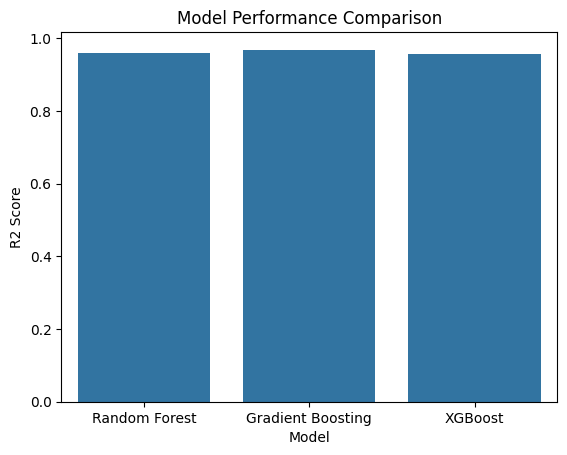

In [18]:
sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Performance Comparison")
plt.show()